In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
import os

#Fonctions d'erreur à fitter#



In [54]:
def erreur(x,Imax,x0,w):
    return (Imax/2)*(1-erf(np.sqrt(2)*(x-x0)/w))

In [ ]:
donnees = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS')

distance = [float(i.replace('cm','').replace('_','.')) for i in donnees]

elDic = dict(zip(distance,donnees)) #permet de trier les valeurs selon la distance
laDica = dict(sorted(elDic.items())) #me creer un dictionnaire qui est ordonné selon la distance
for i in laDica:
    print(laDica[i])
    spectre = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS\\{laDica[i]}')
    plt.scatter(spectre[1:,0],spectre[1:,1])
    plt.show()

In [155]:
ws = np.zeros(24)
for k,i in enumerate(laDica):
    spectre = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS\\{laDica[i]}')
    x = spectre[1:,0]
    y = spectre[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    #print(laDica[i])
    #X = np.arange(min(x),max(x))
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt),color='black')
    #plt.show()

2.664405436783866 274.85024752930326
0.5559104452491938 251.9682641768505
0.5228042856608532 250.91143177379618
1.2944979447499374 267.1623395490464
0.35808467093188273 254.79815125875925
0.3259920371849965 255.97201270075993
0.3128802144187629 258.0432860649016
0.289664004303292 261.281014913748
0.2543462783195343 263.5696484467843
0.22072988373352428 264.93494938562264
0.162963241622608 264.0558670568966
0.255303122857118 271.5079855521248
0.2778261706049896 272.3899268760472
0.2524222962865746 279.1781628878462
0.4536271193586684 275.32522106592324
0.446073657987686 283.95880775209395
0.5719071436636332 359.0759654798499
0.44443189817251133 455.5338692016594
0.28157957890924556 579.1428820083922
0.36772830725375877 708.625010006552
0.5456755917285958 819.6645508669529
0.8512194083130242 952.9473478801441
0.6174370425725757 1081.3753850569544
0.8779532343261084 1122.8377466520562


240.22608494153818 11.990568517200836


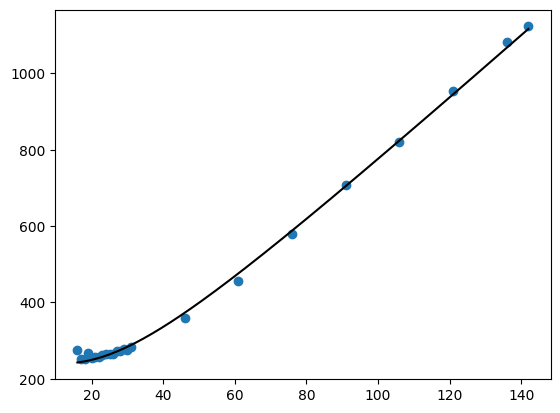

In [156]:
z = np.array(list(laDica.keys()))
def courbeQuad(z,w0,z0): #rappel w est en micron et z en cm
    zR = np.pi*(w0*1e-06)**2/(632.8*1e-09)
    
    return w0 * np.sqrt(1+ ((z-z0)/(zR*100))**2) #ici il fallait convertir zR dans les mêmes unités que z

w0_0 = ws.min()
z0_0 = z[ws.argmin()]
p0 = [w0_0,z0_0]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt,pcov = curve_fit(courbeQuad,z,ws,p0=p0,bounds=bounds, maxfev=200000)
w0_fit, z0_fit = popt
print(w0_fit, z0_fit)

Z = np.linspace(z.min(),z.max(),200)
plt.scatter(z,ws)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
plt.savefig('graphes\\fitz0.png')


In [157]:
zRfit0 = (w0_fit*1e-06)**2*np.pi/(632.8*1e-09)*100
print(f'zR={zRfit0:.2f}m')

zR=28.65m


In [209]:
def UnSurq_z(q,A,B,C,D):
    return  ( C+D*(1/q) ) / ( A + B*(1/q) )

q_z1 = 1j*zRfit0
unsurq2 = UnSurq_z(q_z1,1,3,0,1)
q_z2 = 1/unsurq2
unsurq3 = UnSurq_z(q_z2,1,0,-1/20,1)
w_z1lentille_carré = -1/(unsurq3.imag)*632.8e-09/np.pi #il s'agit de la valeur à la postion de la lentille donc je pourrais prendre les matrice de déplacement en créer plusieurs avec une for loop, collecter les points pour des z dans ma zone d'échantillonage
w_z1lentille_carré
unsurq3

(-0.04638475425763229-0.0345255255187356j)

In [ ]:
donnees1lentille = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille1')

distance1lent = [float(i.replace('cm','').replace('_l1','.')) for i in donnees1lentille]

dic1lent_no = dict(zip(distance1lent,donnees1lentille)) #permet de trier les valeurs selon la distance
dic1lent = dict(sorted(dic1lent_no.items())) #me creer un dictionnaire qui est ordonné selon la distance
for i in dic1lent:
    print(dic1lent[i])
    spectre1lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille1\\{dic1lent[i]}')
    plt.scatter(spectre1lent[1:,0],spectre1lent[1:,1])
    plt.show()

In [192]:
ws1lent = np.zeros(len(dic1lent))
for k,i in enumerate(dic1lent):
    spectre1lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille1\\{dic1lent[i]}')
    x = spectre1lent[1:,0]
    y = spectre1lent[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws1lent[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    #print(dic1lent[i])
    #X = np.arange(min(x),max(x))
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt),color='black')
    #plt.show()

0.5872381810960771 170.77495508151515
0.6605076218863941 171.06640768416904
0.5520694525699366 173.11767175055056
0.7446934891246514 161.7956696080224
2.7591485460612577 142.69408701031347
2.696429535935041 144.97400703342672
1.8595169500673017 150.4771673672845
1.3817414730238808 168.1494976015451
0.39487353742947945 165.65384009504112
0.6757668808293646 170.410072986934
0.4283769289074073 167.64469877616398
0.5194946916018643 239.93972406807674
0.8759224898649725 329.0019601060734
0.8257623529673522 453.1332933964857
1.201708926148256 545.0539684573204
1.398184594138178 632.2693882725869
2.60132122383337 730.8919112068294


171.98794036331165 21.342918809232607


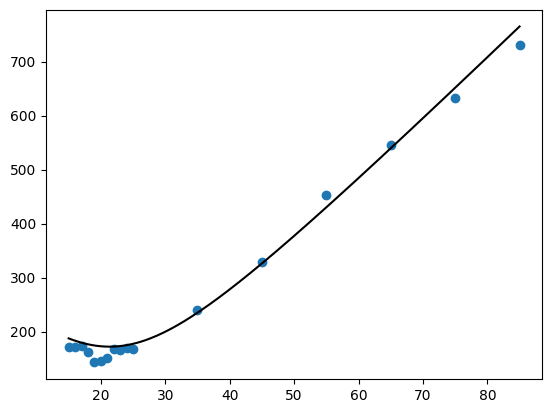

In [193]:
z_1lent = np.array(list(dic1lent.keys()))

w0_1 = ws1lent.min()
z0_1 = z[ws1lent.argmin()]
p01 = [w0_1,z0_1]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt,pcov = curve_fit(courbeQuad,z_1lent,ws1lent,p0=p01,bounds=bounds, maxfev=200000)
w01_fit, z01_fit = popt
print(w01_fit, z01_fit)

Z = np.linspace(z_1lent.min(),z_1lent.max(),200)
plt.scatter(z_1lent,ws1lent)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
plt.savefig('graphes\\fitz0_1.png')


0
[145.07614241   0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.        ]
1
[145.07614241 147.24770149   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.        ]
2
[145.07614241 147.24770149 150.68782046   0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.        ]
3
[145.07614241 147.24770149 150.68782046 155.31222752   0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.        ]
4
[145.07614241 147.24770149 150.68782046 155.31222752 161.01891796
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.


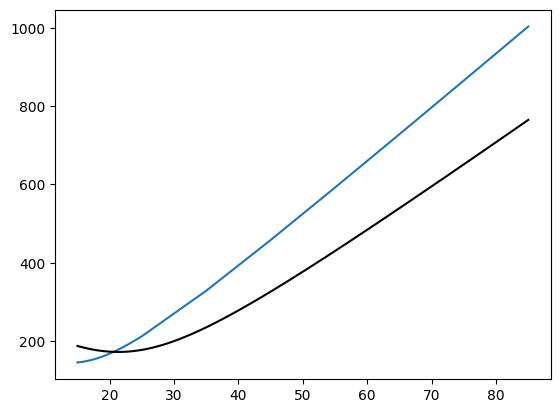

In [230]:
w_z3 = np.zeros(len(dic1lent))
for k,i in enumerate(z_1lent):
    print(k)
    Q = (UnSurq_z(1/unsurq3,1,i,0,1).imag)
    w_z3[k] = np.sqrt( -(632.8e-09)/(np.pi*Q))
    print(w_z3*1e5)
    
plt.plot(z_1lent,w_z3*1e5)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
